In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Funnel Analysis/Sales - Marketing customer dataset.csv")
df

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,24996,Female,24.0,UK,New York,2023-10-23 00:00:00,2024-03-02 00:00:00,Referral,Desktop,Monthly,...,3,0,3,UPI,4.0,2,16.96,796.486833,9,0
14996,24997,Male,26.0,Bangladesh,London,2023-01-20 00:00:00,2024-12-03 00:00:00,Google Ads,Mobile,Monthly,...,3,0,2,BKash,NaN,6,23.86,2155.987233,0,0
14997,24998,Male,42.0,USA,Dhaka,2022-10-11 00:00:00,2023-12-04 00:00:00,Organic,Desktop,Monthly,...,3,0,5,UPI,4.0,4,12.55,614.326226,14,0
14998,24999,Female,31.0,UK,Dhaka,2022-04-01 00:00:00,2024-11-11 00:00:00,Facebook Ads,Desktop,Monthly,...,5,1,1,UPI,3.0,1,19.03,849.936622,8,1


In [ ]:
df.shape

(15000, 30)

In [ ]:
df.columns.tolist()

['customer_id',
 'gender',
 'age',
 'country',
 'city',
 'signup_date',
 'last_purchase_date',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'coupon_code',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'payment_method',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'churn']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,738
age,1200
country,0
city,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0


In [ ]:
df = df.drop(columns=['city'])

In [ ]:
df['gender'] = df['gender'].fillna('Unknown')

In [ ]:
df['age'] = df['age'].apply(lambda x: np.nan if x < 0 else x)

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df = df[(df['age'] >= 10) & (df['age'] <= 90)]

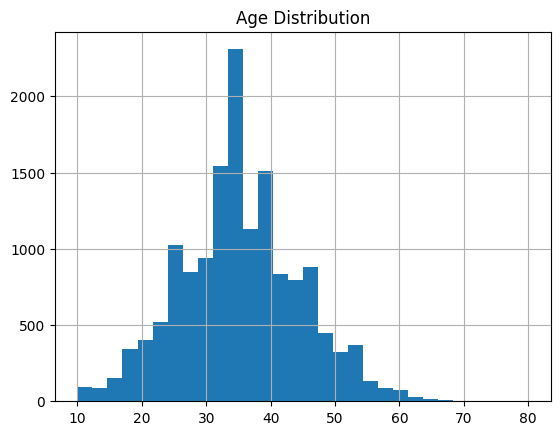

In [ ]:
df['age'].hist(bins=30)
plt.title('Age Distribution')
plt.show()

In [ ]:
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].median())
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())
df['coupon_code'] = df['coupon_code'].fillna('NO_COUPON')

In [ ]:
df = df.copy()

In [ ]:
df

,customer_id,gender,age,country,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,Unknown,35.0,Germany,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,24996,Female,24.0,UK,2023-10-23 00:00:00,2024-03-02 00:00:00,Referral,Desktop,Monthly,0,...,3,0,3,UPI,4.0,2,16.96,796.486833,9,0
14996,24997,Male,26.0,Bangladesh,2023-01-20 00:00:00,2024-12-03 00:00:00,Google Ads,Mobile,Monthly,0,...,3,0,2,BKash,4.0,6,23.86,2155.987233,0,0
14997,24998,Male,42.0,USA,2022-10-11 00:00:00,2023-12-04 00:00:00,Organic,Desktop,Monthly,0,...,3,0,5,UPI,4.0,4,12.55,614.326226,14,0
14998,24999,Female,31.0,UK,2022-04-01 00:00:00,2024-11-11 00:00:00,Facebook Ads,Desktop,Monthly,1,...,5,1,1,UPI,3.0,1,19.03,849.936622,8,1


In [ ]:
df['age'] = df['age'].astype(int)

In [ ]:
df['never_purchased'] = df['last_purchase_date'].isnull().astype(int)

In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
country,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0
is_premium_user,0


In [ ]:
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'], errors='coerce')

In [ ]:
ref = pd.Timestamp('2025-04-01')
df['days_since_last_purchase'] = (ref - df['last_purchase_date']).dt.days
df['customer_tenure_days'] = (ref - df['signup_date']).dt.days

In [ ]:
df

,customer_id,gender,age,country,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,...,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,never_purchased,days_since_last_purchase,customer_tenure_days
0,10001,Male,52,India,2022-05-10,2024-12-31,Email,Tablet,Annual,1,...,UPI,3.0,10,27.56,915.310827,14,0,0,91,1057
1,10002,Unknown,35,Germany,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,...,BKash,3.0,7,15.15,2079.960938,11,0,0,329,289
2,10003,Female,27,Germany,2023-08-23,2024-04-28,Email,Mobile,Annual,1,...,UPI,5.0,6,13.51,1379.150885,9,0,0,338,587
3,10004,Female,36,India,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,...,PayPal,4.0,6,25.65,774.652684,7,0,0,682,429
4,10005,Male,29,USA,2023-07-21,2024-04-07,Referral,Mobile,Monthly,0,...,BKash,3.0,1,12.39,87.680409,11,0,0,359,620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,24996,Female,24,UK,2023-10-23,2024-03-02,Referral,Desktop,Monthly,0,...,UPI,4.0,2,16.96,796.486833,9,0,0,395,526
14996,24997,Male,26,Bangladesh,2023-01-20,2024-12-03,Google Ads,Mobile,Monthly,0,...,BKash,4.0,6,23.86,2155.987233,0,0,0,119,802
14997,24998,Male,42,USA,2022-10-11,2023-12-04,Organic,Desktop,Monthly,0,...,UPI,4.0,4,12.55,614.326226,14,0,0,484,903
14998,24999,Female,31,UK,2022-04-01,2024-11-11,Facebook Ads,Desktop,Monthly,1,...,UPI,3.0,1,19.03,849.936622,8,1,0,141,1096


In [ ]:
df['revenue_per_visit'] = (df['total_spent'] / df['total_visits']).round(2)

In [ ]:
df['engagement_score'] = (
    (df['total_visits'] / df['total_visits'].max()) * 0.4 +
    (df['avg_session_time'] / df['avg_session_time'].max()) * 0.3 +
    df['email_open_rate'] * 0.3
).round(4)

In [ ]:
df

,customer_id,gender,age,country,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,...,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,never_purchased,days_since_last_purchase,customer_tenure_days,revenue_per_visit,engagement_score
0,10001,Male,52,India,2022-05-10,2024-12-31,Email,Tablet,Annual,1,...,10,27.56,915.310827,14,0,0,91,1057,79.93,0.5094
1,10002,Unknown,35,Germany,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,...,7,15.15,2079.960938,11,0,0,329,289,18.76,0.5354
2,10003,Female,27,Germany,2023-08-23,2024-04-28,Email,Mobile,Annual,1,...,6,13.51,1379.150885,9,0,0,338,587,38.30,0.5261
3,10004,Female,36,India,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,...,6,25.65,774.652684,7,0,0,682,429,27.84,0.5317
4,10005,Male,29,USA,2023-07-21,2024-04-07,Referral,Mobile,Monthly,0,...,1,12.39,87.680409,11,0,0,359,620,57.19,0.2921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,24996,Female,24,UK,2023-10-23,2024-03-02,Referral,Desktop,Monthly,0,...,2,16.96,796.486833,9,0,0,395,526,5.46,0.6002
14996,24997,Male,26,Bangladesh,2023-01-20,2024-12-03,Google Ads,Mobile,Monthly,0,...,6,23.86,2155.987233,0,0,0,119,802,27.54,0.5820
14997,24998,Male,42,USA,2022-10-11,2023-12-04,Organic,Desktop,Monthly,0,...,4,12.55,614.326226,14,0,0,484,903,62.26,0.3927
14998,24999,Female,31,UK,2022-04-01,2024-11-11,Facebook Ads,Desktop,Monthly,1,...,1,19.03,849.936622,8,1,0,141,1096,41.67,0.3797


In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
country,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0
is_premium_user,0


In [ ]:
float_cols = df.select_dtypes(include='float').columns.tolist()
df[float_cols] = df[float_cols].round(2)
df.to_csv('cleaned_data.csv', index=False)
df.head()

,customer_id,gender,age,country,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,...,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,never_purchased,days_since_last_purchase,customer_tenure_days,revenue_per_visit,engagement_score
0,10001,Male,52,India,2022-05-10,2024-12-31,Email,Tablet,Annual,1,...,10,27.56,915.31,14,0,0,91,1057,79.93,0.51
1,10002,Unknown,35,Germany,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,...,7,15.15,2079.96,11,0,0,329,289,18.76,0.54
2,10003,Female,27,Germany,2023-08-23,2024-04-28,Email,Mobile,Annual,1,...,6,13.51,1379.15,9,0,0,338,587,38.30,0.53
3,10004,Female,36,India,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,...,6,25.65,774.65,7,0,0,682,429,27.84,0.53
4,10005,Male,29,USA,2023-07-21,2024-04-07,Referral,Mobile,Monthly,0,...,1,12.39,87.68,11,0,0,359,620,57.19,0.29


In [ ]:
df.to_csv('funnel_cleaned_data.csv', index=False)